In [1]:
# E3 — Modelado Analítico y Métricas Derivadas


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Rutas
GOLD_DIR = Path("../outputs/gold")

# Carga de tablas gold
businesses  = pd.read_csv(GOLD_DIR / "businesses_enriched.csv")
categories  = pd.read_csv(GOLD_DIR / "categories_agg.csv")
monthly     = pd.read_csv(GOLD_DIR / "monthly_reviews.csv", parse_dates=["date"])
reviews     = pd.read_csv(GOLD_DIR / "reviews_lite.csv", parse_dates=["date"])

print(f"businesses : {len(businesses):,} filas, {businesses.shape[1]} columnas")
print(f"categories : {len(categories):,} filas, {categories.shape[1]} columnas")
print(f"monthly    : {len(monthly):,} filas, {monthly.shape[1]} columnas")
print(f"reviews    : {len(reviews):,} filas, {reviews.shape[1]} columnas")

businesses : 119,698 filas, 16 columnas
categories : 687 filas, 5 columnas
monthly    : 202 filas, 3 columnas
reviews    : 775,955 filas, 8 columnas


In [2]:
#ESTRUCTURA RELACIONAL Y CARDINALIDAD


# Relación businesses → reviews (1:N)
match = reviews["business_id"].isin(businesses["business_id"])
print("=== Validación de cardinalidad ===")
print(f"Reviews con business_id válido : {match.sum():,} ({match.mean():.1%})")
print(f"Reviews sin match              : {(~match).sum():,}")
print(f"Negocios únicos en reviews     : {reviews['business_id'].nunique():,}")
print(f"Negocios únicos en businesses  : {businesses['business_id'].nunique():,}")

# Duplicados
print(f"\nDuplicados en businesses : {businesses.duplicated('business_id').sum()}")
print(f"Duplicados en reviews    : {reviews.duplicated('review_id').sum()}")

=== Validación de cardinalidad ===
Reviews con business_id válido : 592,501 (76.4%)
Reviews sin match              : 183,454
Negocios únicos en reviews     : 9,930
Negocios únicos en businesses  : 119,698

Duplicados en businesses : 0
Duplicados en reviews    : 0


In [3]:
#COMPARATIVA DE ESTRUCTURAS ANALÍTICAS

# OPCIÓN A: Tabla desnormalizada (una fila por negocio con métricas agregadas)
# → Lo que tenemos en businesses_enriched.csv
opcion_a = businesses[["business_id", "stars", "review_count", 
                         "divergence_score", "quadrant", "primary_category", "state"]]

# OPCIÓN B: Tabla explotada (una fila por categoría-negocio)
# → Más granular, permite análisis por categoría secundaria
opcion_b = businesses.copy()
opcion_b["categories_list"] = opcion_b["categories"].fillna("Unknown").str.split(",")
opcion_b = opcion_b.explode("categories_list")
opcion_b["category_clean"] = opcion_b["categories_list"].str.strip()
opcion_b = opcion_b[opcion_b["category_clean"] != ""]

print("=== Comparativa de estructuras ===\n")
print(f"Opción A — Tabla desnormalizada (1 fila por negocio)")
print(f"  Filas       : {len(opcion_a):,}")
print(f"  Granularidad: negocio")
print(f"  Ventaja     : simple, directa, sin duplicación de métricas")
print(f"  Limitación  : pierde categorías secundarias del negocio\n")

print(f"Opción B — Tabla explotada (1 fila por categoría-negocio)")
print(f"  Filas       : {len(opcion_b):,}")
print(f"  Granularidad: categoría × negocio")
print(f"  Ventaja     : permite filtrar por cualquier categoría del negocio")
print(f"  Limitación  : duplica métricas del negocio (stars, review_count)")

print(f"\n→ DECISIÓN: Opción A para el dashboard principal.")
print(f"  Opción B se usa solo en categories_agg.csv para análisis por categoría.")
print(f"  Esto evita duplicación de KPIs y mantiene integridad de métricas.")

=== Comparativa de estructuras ===

Opción A — Tabla desnormalizada (1 fila por negocio)
  Filas       : 119,698
  Granularidad: negocio
  Ventaja     : simple, directa, sin duplicación de métricas
  Limitación  : pierde categorías secundarias del negocio

Opción B — Tabla explotada (1 fila por categoría-negocio)
  Filas       : 538,559
  Granularidad: categoría × negocio
  Ventaja     : permite filtrar por cualquier categoría del negocio
  Limitación  : duplica métricas del negocio (stars, review_count)

→ DECISIÓN: Opción A para el dashboard principal.
  Opción B se usa solo en categories_agg.csv para análisis por categoría.
  Esto evita duplicación de KPIs y mantiene integridad de métricas.


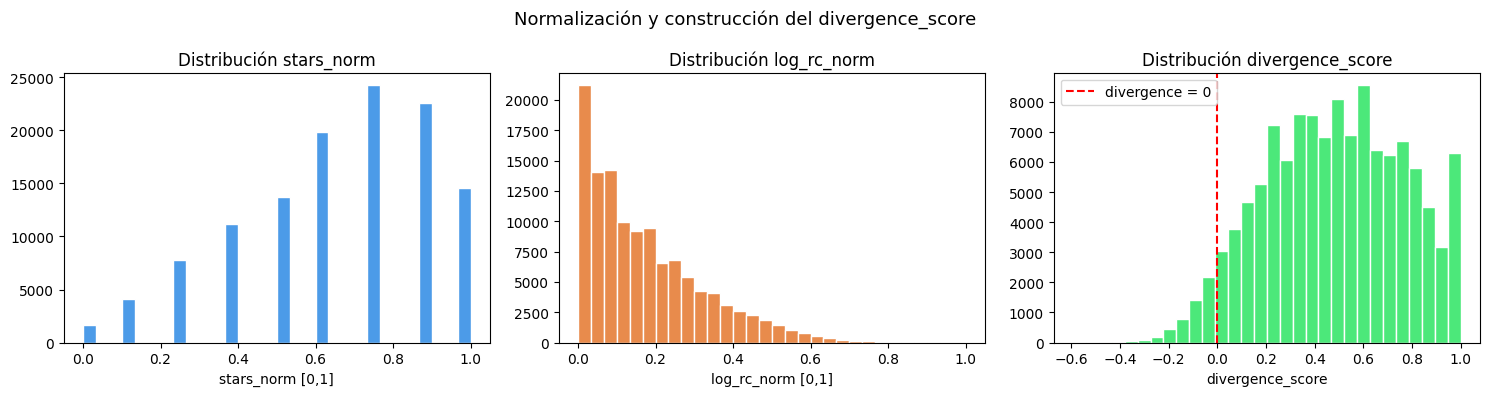


Negocios con divergence > 0 (calidad > popularidad) : 113,663
Negocios con divergence < 0 (popularidad > calidad) : 5,572


In [4]:
# JUSTIFICACIÓN DEL DIVERGENCE_SCORE

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Stars norm
axes[0].hist(businesses["stars_norm"], bins=30, color="#4C9BE8", edgecolor="white")
axes[0].set_title("Distribución stars_norm")
axes[0].set_xlabel("stars_norm [0,1]")

# log_rc_norm
axes[1].hist(businesses["log_rc_norm"], bins=30, color="#E88B4C", edgecolor="white")
axes[1].set_title("Distribución log_rc_norm")
axes[1].set_xlabel("log_rc_norm [0,1]")

# divergence_score
axes[2].hist(businesses["divergence_score"], bins=30, color="#4CE87A", edgecolor="white")
axes[2].axvline(0, color="red", linestyle="--", label="divergence = 0")
axes[2].set_title("Distribución divergence_score")
axes[2].set_xlabel("divergence_score")
axes[2].legend()

plt.suptitle("Normalización y construcción del divergence_score", fontsize=13)
plt.tight_layout()
plt.savefig("../outputs/gold/divergence_distribution.png", dpi=150)
plt.show()

print(f"\nNegocios con divergence > 0 (calidad > popularidad) : {(businesses['divergence_score'] > 0).sum():,}")
print(f"Negocios con divergence < 0 (popularidad > calidad) : {(businesses['divergence_score'] < 0).sum():,}")

=== Resumen por cuadrante ===
                                n_negocios  avg_stars  avg_reviews  avg_divergence
quadrant                                                                          
High Q / Low Pop (Oportunidad)       90142      4.025       30.552           0.595
High Q / High Pop                     4743      3.977      472.584           0.159
Low Q / High Pop                       142      2.271      386.380          -0.245
Low Q / Low Pop                      24671      2.074       21.793           0.134


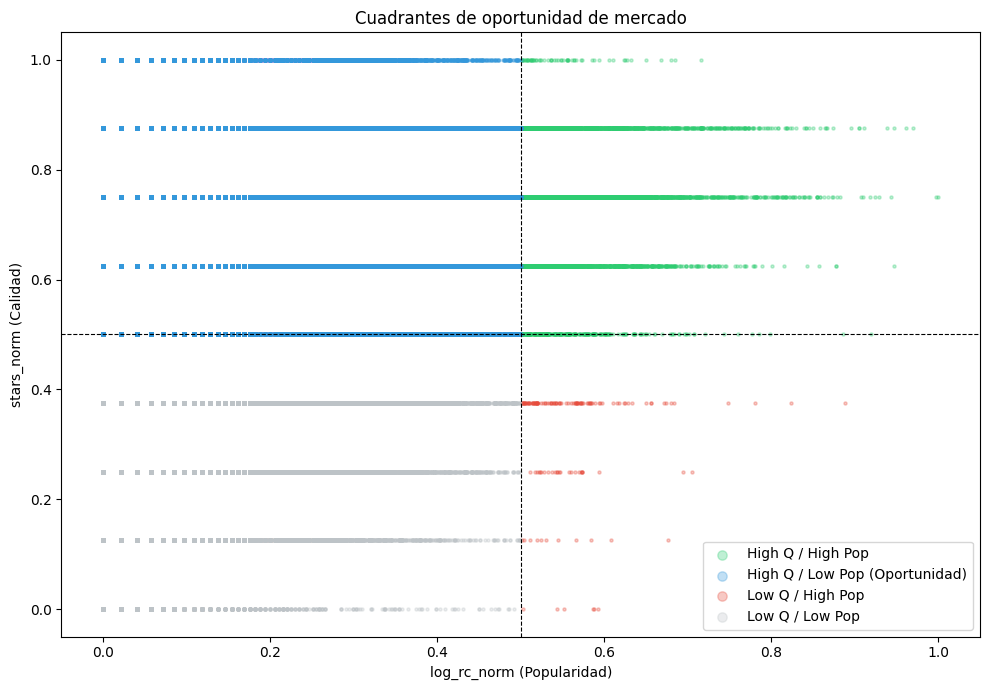

In [5]:
#VALIDACIÓN DE CUADRANTES DE OPORTUNIDAD

quadrant_summary = (
    businesses.groupby("quadrant")
    .agg(
        n_negocios     =("business_id", "count"),
        avg_stars      =("stars", "mean"),
        avg_reviews    =("review_count", "mean"),
        avg_divergence =("divergence_score", "mean"),
    )
    .round(3)
    .sort_values("avg_stars", ascending=False)
)
print("=== Resumen por cuadrante ===")
print(quadrant_summary.to_string())

# Scatter cuadrantes
fig, ax = plt.subplots(figsize=(10, 7))
colors = {
    "High Q / High Pop"            : "#2ecc71",
    "High Q / Low Pop (Oportunidad)": "#3498db",
    "Low Q / High Pop"             : "#e74c3c",
    "Low Q / Low Pop"              : "#bdc3c7",
}
for q, grp in businesses.groupby("quadrant"):
    ax.scatter(grp["log_rc_norm"], grp["stars_norm"],
               alpha=0.3, s=5, color=colors.get(q, "gray"), label=q)

ax.axhline(0.5, color="black", linestyle="--", linewidth=0.8)
ax.axvline(0.5, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("log_rc_norm (Popularidad)")
ax.set_ylabel("stars_norm (Calidad)")
ax.set_title("Cuadrantes de oportunidad de mercado")
ax.legend(markerscale=3, loc="lower right")
plt.tight_layout()
plt.savefig("../outputs/gold/quadrant_scatter.png", dpi=150)
plt.show()

In [7]:
# HALLAZGO CRÍTICO — Validación de cardinalidad reviews

print("=== Análisis del 23.6% de reviews sin match ===\n")

# Reviews sin match
sin_match = reviews[~reviews["business_id"].isin(businesses["business_id"])]

print(f"Reviews sin match: {len(sin_match):,}")
print(f"\nDistribución por año:")
print(sin_match["date"].dt.year.value_counts().sort_index().to_string())

print(f"\nNegocios únicos en reviews sin match: {sin_match['business_id'].nunique():,}")
print(f"→ Son negocios cerrados (is_open=0) excluidos en bronze.")
print(f"  Decisión: aceptable. El análisis de oportunidad requiere negocios activos.")
print(f"  Los 183,454 reviews corresponden a negocios que filtramos intencionalmente.")

=== Análisis del 23.6% de reviews sin match ===

Reviews sin match: 183,454

Distribución por año:
date
2005       36
2006      349
2007     2186
2008     5322
2009     8720
2010    13567
2011    17008
2012    18137
2013    19762
2014    20506
2015    19750
2016    17568
2017    15976
2018    13009
2019     8919
2020     2113
2021      522
2022        4

Negocios únicos en reviews sin match: 2,801
→ Son negocios cerrados (is_open=0) excluidos en bronze.
  Decisión: aceptable. El análisis de oportunidad requiere negocios activos.
  Los 183,454 reviews corresponden a negocios que filtramos intencionalmente.


In [6]:
# DECISIONES DE MODELADO — RESUMEN EJECUTIVO

resumen = pd.DataFrame([
    {
        "Decisión"     : "Estructura desnormalizada (Opción A)",
        "Justificación": "Evita duplicación de KPIs; suficiente para pregunta analítica",
        "Alternativa descartada": "Tabla explotada por categoría (Opción B)",
        "Razón del descarte": "Duplica stars y review_count por cada categoría secundaria",
    },
    {
        "Decisión"     : "divergence_score = stars_norm - log_rc_norm",
        "Justificación": "Captura negocios de alta calidad y baja visibilidad (joyas ocultas)",
        "Alternativa descartada": "Ratio stars / review_count sin normalizar",
        "Razón del descarte": "Sensible a escala; no comparable entre categorías",
    },
    {
        "Decisión"     : "Umbral de cuadrante en 0.5 (configurable)",
        "Justificación": "Punto medio de la escala normalizada; ajustable vía pipeline.yaml",
        "Alternativa descartada": "Percentil 75 como umbral",
        "Razón del descarte": "Reduce demasiado el cuadrante de oportunidad; menos accionable",
    },
    {
        "Decisión"     : "categories_agg como tabla separada",
        "Justificación": "Permite análisis por categoría sin explotar la tabla principal",
        "Alternativa descartada": "Join en Tableau entre businesses y tabla explotada",
        "Razón del descarte": "Genera fanout en métricas; complica cálculos LOD en Tableau",
    },
])

print("=== Tabla de decisiones de modelado ===\n")
print(resumen.to_string(index=False))

=== Tabla de decisiones de modelado ===

                                   Decisión                                                       Justificación                             Alternativa descartada                                             Razón del descarte
       Estructura desnormalizada (Opción A)       Evita duplicación de KPIs; suficiente para pregunta analítica           Tabla explotada por categoría (Opción B)     Duplica stars y review_count por cada categoría secundaria
divergence_score = stars_norm - log_rc_norm Captura negocios de alta calidad y baja visibilidad (joyas ocultas)          Ratio stars / review_count sin normalizar              Sensible a escala; no comparable entre categorías
  Umbral de cuadrante en 0.5 (configurable)   Punto medio de la escala normalizada; ajustable vía pipeline.yaml                           Percentil 75 como umbral Reduce demasiado el cuadrante de oportunidad; menos accionable
         categories_agg como tabla separada      Permit